<a href="https://colab.research.google.com/github/Barna036/Intro-to-Python1/blob/main/Day_4_Pandas_Practice__with_Viz_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4: pandas

 We'll walk through:

- Importing pandas
- Series (1D) and DataFrames (2D)
- Filtering, updating, and indexing
- Summarizing data
- Loading real data from a CSV
- GroupBy and aggregation
- Merging DataFrames
- Handling missing values
- String operations on columns
- `.apply()` with lambdas
- Basic plotting

Run cells top to bottom. Future cells may depend on past cells.

## Setup

By convention we import pandas as `pd`:

In [1]:
import pandas as pd
import numpy as np

## Series

A **Series** is a 1D array with an associated **index** (data labels).

In [2]:
obj = pd.Series([4, 7, -5, 3])
obj  # default indicies are 0 through 3

,0
0,4
1,7
2,-5
3,3


Default indices are `0, 1, 2, ...`. You can supply your own:

In [3]:
test_scores = pd.Series([88, 75, 95, 83],
                        index=["Will", "Ben", "Adam", "Charlie"])
test_scores

,0
Will,88
Ben,75
Adam,95
Charlie,83


In [4]:
# Access by label
test_scores["Ben"]

np.int64(75)

## Data alignment

If you do arithmetic on two Series, pandas matches by **label** rather than position.

In [7]:
states1 = pd.Series([500, 250, 300],
                    index=["Alaska", "Kansas", "Ohio"])
states2 = pd.Series([1000, 300, 1300],
                    index=["Kansas", "Alaska", "Ohio"])

states1 + states2

,0
Alaska,800
Kansas,1250
Ohio,1600


Even though Alaska and Kansas are in different positions, pandas adds the right values together. Like a SQL or `dplyr` join, with the index as the key.

In [8]:
# You can name the index for clarity
states1.index.name = "state"
states1

,0
state,
Alaska,500
Kansas,250
Ohio,300


### Your Turn — Series basics

Create a Series called `populations` containing the populations (in millions) of these states:

- Ohio: 11.8
- Florida: 22.6
- Pennsylvania: 13.0
- Michigan: 10.1

Then:
1. Print the population of Florida
2. Print all populations greater than 12 million (hint: `populations[populations > 12]`)

In [22]:
# your code here

populations = pd.Series([11.8, 22.6, 13.0, 10.1],
                    index=["Ohio", "Florida","pennsylvania", "Michigan"])
populations2 = pd.Series([11.8, 2.6, 13.0, 10.1],
                    index=["Ohio", "Florida","pennsylvania", "Michigan"])
populations["Florida"]
populations[populations > 12]  # for the numeric, they
populations[populations2 > 12]  # for2ill list the new one
#for series itself the name
#populations.index.name = "state"

,0
pennsylvania,13.0


## DataFrame

A **DataFrame** is a 2D table — basically a dict of Series sharing the same index. Build one from a dict of lists:

In [23]:
data = {
    "state": ["Ohio", "Ohio", "Ohio", "Nevada", "Nevada", "Nevada"],
    "year":  [2000, 2001, 2002, 2001, 2002, 2003],
    "pop":   [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]
}

frame = pd.DataFrame(data)
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


### Common methods

In [ ]:
frame.head()   # first 5 rows

,state,year,pop
Ohio_1,Ohio,2000,1.5
Ohio_2,Ohio,2001,1.7
Ohio_3,Ohio,2002,3.6
Nevada_1,Nevada,2001,2.4
Nevada_2,Nevada,2002,2.9


In [ ]:
frame.tail()   # last 5 rows

,state,year,pop
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


### Accessing columns

Single column (returns a Series):

In [ ]:
frame["state"]

,state
Ohio_1,Ohio
Ohio_2,Ohio
Ohio_3,Ohio
Nevada_1,Nevada
Nevada_2,Nevada
Nevada_3,Nevada


Multiple columns (returns a DataFrame):

In [24]:
frame[["state", "pop"]]

,state,pop
0,Ohio,1.5
1,Ohio,1.7
2,Ohio,3.6
3,Nevada,2.4
4,Nevada,2.9
5,Nevada,3.2


## Creating a new column

Make a Series and assign it to a new column name:

In [25]:
val = pd.Series([0.5, 0.49, 0.51, 0.65, 0.59, 0.6])
frame["turnout"] = val
frame

,state,year,pop,turnout
0,Ohio,2000,1.5,0.50
1,Ohio,2001,1.7,0.49
2,Ohio,2002,3.6,0.51
3,Nevada,2001,2.4,0.65
4,Nevada,2002,2.9,0.59
5,Nevada,2003,3.2,0.60


You can also specify which index each entry corresponds to. Missing positions get `NaN`:

In [ ]:
val = pd.Series([0.5, 0.49, 0.51, 0.6], index=[0, 1, 2, 5])
frame["turnout"] = val
frame

,state,year,pop,turnout
0,Ohio,2000,1.5,0.50
1,Ohio,2001,1.7,0.49
2,Ohio,2002,3.6,0.51
3,Nevada,2001,2.4,NaN
4,Nevada,2002,2.9,NaN
5,Nevada,2003,3.2,0.60


## Filtering

Keep only the rows above a turnout threshold:

In [30]:
# Reset turnout first
frame["turnout"] = pd.Series([0.5, 0.49, 0.51, 0.65, 0.59, 0.6])

series2= pd.Series([0.4, 0.59, 0.41, 0.65, 0.59, 0.6])
frame_high = frame[series2> 0.5]
frame_high2 = frame[frame["turnout"]> 0.5]
frame_high

,state,year,pop,turnout
1,Ohio,2001,1.7,0.49
3,Nevada,2001,2.4,0.65
4,Nevada,2002,2.9,0.59
5,Nevada,2003,3.2,0.60


The original indices are retained — pandas doesn't renumber after filtering.

## Updating values: a common mistake

You can update values using a boolean filter — but watch your syntax:

In [34]:
# This zeros out EVERY column of matching rows — almost never what you want
test = frame.copy()
test


,state,year,pop,turnout
0,Ohio,2000,1.5,0.50
1,Ohio,2001,1.7,0.49
2,Ohio,2002,3.6,0.51
3,Nevada,2001,2.4,0.65
4,Nevada,2002,2.9,0.59
5,Nevada,2003,3.2,0.60


In [35]:
test[test["pop"] < 2] = 0
test

,state,year,pop,turnout
0,0,0,0.0,0.00
1,0,0,0.0,0.00
2,Ohio,2002,3.6,0.51
3,Nevada,2001,2.4,0.65
4,Nevada,2002,2.9,0.59
5,Nevada,2003,3.2,0.60


## Updating values: the right way

Use `.loc` to name which column you're updating:

In [37]:
## .loc takes two arguments, the condition and the column to apply it to
test = frame.copy()
test.loc[test["pop"] < 2, "pop"] = 0
test

,state,year,pop,turnout
0,Ohio,2000,0.0,0.50
1,Ohio,2001,0.0,0.49
2,Ohio,2002,3.6,0.51
3,Nevada,2001,2.4,0.65
4,Nevada,2002,2.9,0.59
5,Nevada,2003,3.2,0.60


## Indexing pitfalls — use `.iloc` for positional access

When your Series has integer index labels, `[-1]` doesn't mean "last element" — it tries to find the label `-1`:

In [39]:
ser = pd.Series(np.arange(3.))
ser

,0
0,0.0
1,1.0
2,2.0


In [40]:
# This raises KeyError
try:
    print(ser[-1])
except KeyError as e:
    print("KeyError:", e)

KeyError: -1


`.iloc[]` always uses positional indexing, regardless of the index labels:

In [41]:
ser.iloc[-1]   # 2.0 — the last element #positional indexing regarding the indexing label.

np.float64(2.0)

Use `.iloc` whenever you want positional access. It's always unambiguous.

## Summarizing data

In [ ]:
frame.describe()

,year,pop,turnout
count,6.000000,6.000000,6.000000
mean,2001.500000,2.550000,0.556667
std,1.048809,0.836062,0.065625
min,2000.000000,1.500000,0.490000
25%,2001.000000,1.875000,0.502500
50%,2001.500000,2.650000,0.550000
75%,2002.000000,3.125000,0.597500
max,2003.000000,3.600000,0.650000


In [43]:
# Correlation between two columns
frame["pop"].corr(frame["turnout"])

np.float64(0.33900314470088466)

In [42]:
# Covariance matrix
frame[["pop", "turnout", "year"]].cov()

,pop,turnout,year
pop,0.6990,0.018600,0.750
turnout,0.0186,0.004307,0.026
year,0.7500,0.026000,1.100


## Loading real data

Generic pattern:

```python
df = pd.read_csv("path/to/file.csv")
```

In Colab, upload your file via the folder icon on the left sidebar — it lives at `/content/your_file.csv`.

For class, we'll load the ANES 2020 subset:

In [45]:
# Adjust the path to wherever you uploaded the file

nes = pd.read_csv("/nes2020_subset.csv")

nes.head()

,Unnamed: 0,ID,state,attend_online,attend_meet,buttons_signs,donate,contact_congr,registered,party,...,act_ineq,hist_discrim,econ_mobility,tax_rich,aca,vaccines,reg_emissions,background_checks,freetrade,minwage
0,1,200015,40.0,No,No,No,No,No,NaN,2.0,...,Favor a great deal,Agree Strongly,A great deal easier,Oppose,Disapprove,Neutral,Neutral,Disapprove,Approve,Same
1,2,200022,16.0,Yes,Yes,No,No,No,NaN,4.0,...,Neutral,Disagree Somewhat,A great deal harder,Favor,Disapprove,Neutral,Neutral,Neutral,Neutral,Raised
2,3,200039,51.0,No,No,Yes,Yes,Yes,NaN,NaN,...,Favor a moderate amount,Agree Strongly,A little harder,Favor,Approve,Approve,Approve,Approve,Neutral,Raised
3,4,200046,6.0,No,No,No,No,No,NaN,2.0,...,Favor a moderate amount,Disagree Somewhat,A great deal harder,Favor,Approve,Approve,Approve,Approve,Approve,Same
4,5,200053,8.0,No,No,No,No,No,NaN,4.0,...,Neutral,Agree somewhat,A great deal harder,Neutral,Neutral,Disapprove,Disapprove,Approve,Disapprove,Eliminated


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
nes.shape   # (rows, columns)

(7453, 36)

In [51]:
nes.describe()

,Unnamed: 0,ID,state,registered,party,ft_biden,ft_trump,ft_harris,ft_pence,ft_fauci,ft_scotus,ft_congress,ft_police,ft_science,ft_blm,limit_imports
count,7453.000000,7453.000000,7051.000000,625.000000,3970.000000,7375.000000,7359.000000,7347.000000,7362.000000,7293.000000,7367.000000,7355.000000,7388.000000,7367.000000,7344.000000,7244.000000
mean,3727.000000,336416.233061,28.084527,2.352000,2.084635,53.449220,38.258051,51.896965,45.277234,67.916084,60.658341,44.346975,70.574851,79.313832,53.295615,1.444644
std,2151.640111,103653.120687,15.736841,0.884844,1.220424,35.814618,40.092051,37.828472,37.295162,30.240530,21.831983,21.720761,25.125874,20.167552,35.431626,0.496961
min,1.000000,200015.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1864.000000,225427.000000,13.000000,1.000000,1.000000,15.000000,0.000000,10.000000,5.000000,50.000000,50.000000,30.000000,60.000000,70.000000,15.000000,1.000000
50%,3727.000000,335416.000000,27.000000,3.000000,2.000000,60.000000,15.000000,60.000000,50.000000,70.000000,60.000000,50.000000,70.000000,85.000000,60.000000,1.000000
75%,5590.000000,427865.000000,42.000000,3.000000,4.000000,85.000000,85.000000,85.000000,85.000000,100.000000,75.000000,60.000000,85.000000,100.000000,85.000000,2.000000
max,7453.000000,535469.000000,56.000000,3.000000,5.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2.000000


### Frequency tables

`.value_counts()` counts unique values in a column — the pandas analog to R's `table()`.

In [52]:
nes["freetrade"].value_counts()

,count
freetrade,
Approve,3386
Neutral,3360
Disapprove,607


### Your Turn — explore the data

Using the `nes` DataFrame:

1. Print the column names (`nes.columns`)
2. Compute the mean of `ft_biden`
3. Make a frequency table for the `aca` column (Affordable Care Act views)
4. Filter `nes` to only rows where `ft_biden > 80` and print how many rows that is

In [66]:
# your code here
nes.columns
#nes["ft_biden"].mean()
nes["aca"].value_counts()
biden_high= nes[ nes["ft_biden"] > 80]
nes[nes["ft_biden"] > 80].shape


(2411, 36)

## GroupBy and aggregation

Split your data into groups, compute something per group, recombine. The R equivalent is `dplyr::group_by() |> summarise()`.

In [69]:
# Mean Biden feeling thermometer by party

nes.groupby("party")["ft_biden"].std() #what variable we are grouping by (), then tell them over what variable

,ft_biden
party,
1.0,24.479702
2.0,28.850518
4.0,32.363335
5.0,37.606541


Aggregate multiple columns at once:

In [75]:
nes.groupby("party")[["ft_biden", "ft_trump", "ft_fauci"]].mean()

,ft_biden,ft_trump,ft_fauci
party,,,
1.0,77.805263,10.996479,83.263685
2.0,24.833470,73.347826,51.632450
4.0,54.229102,34.037306,68.204167
5.0,47.575758,42.575758,62.343750


Different functions for different columns with `.agg()`:

In [79]:
nes.groupby("party").agg(ft_biden_mean = ("ft_biden", "mean"), ft_trump_sd = ("ft_trump", "std"))


,ft_biden_mean,ft_trump_sd
party,,
1.0,77.805263,24.477799
2.0,24.833470,32.023705
4.0,54.229102,36.415603
5.0,47.575758,39.273106


## Merging DataFrames

Real analyses combine multiple datasets. `pd.merge()` does this, with options that mirror SQL / `dplyr` joins.

In [77]:
state_pop = pd.DataFrame({
    "state":        ["Ohio", "Nevada", "Wyoming"],
    "population_m": [11.8, 3.2, 0.6],
})

state_gdp = pd.DataFrame({
    "state": ["Ohio", "Nevada", "California"],
    "gdp_b": [770, 220, 3900],
})

**Inner join (default)** — only rows that match in both:

In [81]:
pd.merge(state_pop, state_gdp, on="state")

,state,population_m,gdp_b
0,Ohio,11.8,770
1,Nevada,3.2,220


**Outer join** — keep everything, fill non-matches with `NaN`:

In [80]:
pd.merge(state_pop, state_gdp, on="state", how="outer") # left will drop that doesnt match

,state,population_m,gdp_b
0,California,NaN,3900.0
1,Nevada,3.2,220.0
2,Ohio,11.8,770.0
3,Wyoming,0.6,NaN


`how="left"` keeps everything in the left table, `how="right"` keeps everything in the right.

### Your Turn — group and merge

1. Group `nes` by `aca` and compute the mean `ft_biden` for each level. Which group has the warmest Biden ratings?

2. Build a small DataFrame called `region_map`:

```
state   region
Ohio    Midwest
Nevada  West
Wyoming West
```

Merge it with `state_pop` (defined above) on `state`. What columns are in the result?

In [87]:
# your code here
nes.groupby("aca").ft_biden.mean()
region_map= pd.DataFrame({
    "state": ["Ohio", "Nevada", "Wyoming"],
    "region": ["Midwest", "West", "West"],
})
pd.merge(state_pop, region_map, on="state")

,state,population_m,region
0,Ohio,11.8,Midwest
1,Nevada,3.2,West
2,Wyoming,0.6,West


## Handling missing data

Missing values appear as `NaN`. Three useful methods:

- `.isna()` — which values are missing?
- `.dropna()` — remove rows with missing values
- `.fillna()` — fill missing values with something

In [88]:
# Count missing per column
nes[["ft_biden", "ft_trump", "ft_fauci"]].isna().sum()

,0
ft_biden,78
ft_trump,94
ft_fauci,160


In [ ]:
# Drop rows with any missing values in these columns
clean = nes[["ft_biden", "ft_trump"]].dropna()
print(len(nes), "->", len(clean), "rows after dropna")

7453 -> 7319 rows after dropna


In [89]:
# Fill with the column mean
nes["ft_biden"].fillna(nes["ft_biden"].mean()).head()

,ft_biden
0,0.0
1,15.0
2,85.0
3,100.0
4,0.0


Always think about *why* values are missing before dropping them. Missingness is often informative — refusal to rate a politician on a feeling thermometer means something!

## String operations: the `.str` accessor

When you have a column of strings, `.str` lets you apply string methods element-wise. Same methods you saw on Day 1, but applied over the whole column.

In [93]:
# Uppercase every value — .head() just shows a preview, doesn't reassign
nes["aca"].str.lower().head()

,aca
0,Disapprove
1,Disapprove
2,Approve
3,Approve
4,Neutral


In [94]:
# Does the value contain a substring?
nes["aca"].str.contains("Approve", na=False, case= False).head()

,aca
0,True
1,True
2,True
3,True
4,False


In [ ]:
nes["aca"].head()

,aca
0,Disapprove
1,Disapprove
2,Approve
3,Approve
4,Neutral


`na=False` tells pandas to treat `NaN` as `False` rather than letting it propagate.

In [95]:
# Filter using a string condition, it will return to the false rather NA
approvers = nes[nes["aca"].str.contains("Approve", na=False)]
approvers.shape

(3640, 36)

## `.apply()` with a lambda

Sometimes you need custom logic that no built-in method covers. `.apply()` runs a function on each element. Pair with a `lambda` for short, one-off functions.

In [96]:
nes["biden_class"] = nes["ft_biden"].apply(
    lambda x: "warm" if x > 60
    else ("neutral" if x >= 40
          else "cold")
)

nes["biden_class"].value_counts()

,count
biden_class,
warm,3497
cold,2587
neutral,1369


The `lambda x: ...` is a tiny one-line function. Equivalent to:

```python
def classify(x):
    if x > 60:
        return "warm"
    elif x >= 40:
        return "neutral"
    else:
        return "cold"

nes["biden_class"] = nes["ft_biden"].apply(classify)
```

Lambdas are great for short logic. Named functions are better when the logic is complex or used in multiple places.

### Your Turn — `.str` and `.apply`

1. Use the `.str` accessor to filter `nes` to only rows where `aca` contains "Disapprove". How many rows?

2. Create a new column `trump_class` that classifies `ft_trump` the same way we did for Biden (warm/neutral/cold). Use `.apply` with a lambda.

3. Cross-tab `biden_class` vs `trump_class` to see how respondents feel about both candidates. (Hint: `pd.crosstab(nes["biden_class"], nes["trump_class"])`.)

In [97]:
# your code here
disapprovers = nes[nes["aca"].str.contains("Disapprove", na=False)]
disapprovers.shape



(2312, 37)

In [98]:
trump_class = nes["ft_trump"].apply(
    lambda x: "warm" if x > 60
    else ("neutral" if x >= 40
          else "cold")
)

nes["trump_class"] = trump_class
nes["trump_class"].value_counts()

,count
trump_class,
cold,4117
warm,2473
neutral,863


## Basic plotting

`matplotlib` is the most popular plotting library:

In [102]:
import matplotlib.pyplot as plt

The default `plot()` treats the column as a line — usually not what you want for distributional data:

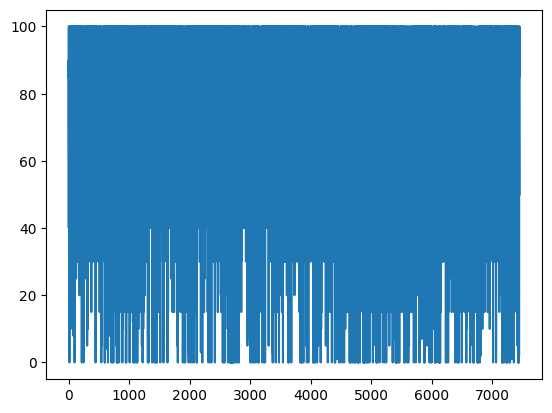

In [103]:
import pandas as pd
nes = pd.read_csv("/nes2020_subset.csv")


plt.plot(nes["ft_police"])
plt.show()

For a distribution, use a histogram:

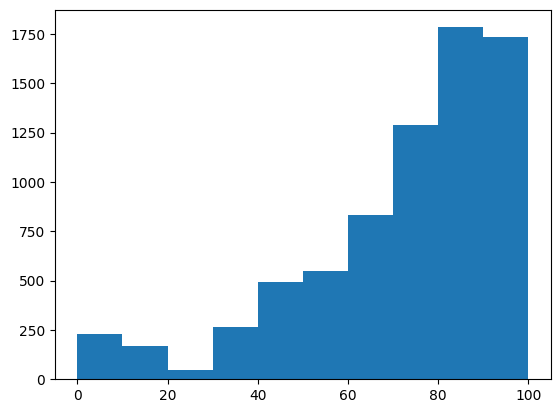

In [104]:
plt.hist(nes["ft_police"])
plt.show()

With axis labels and a title:

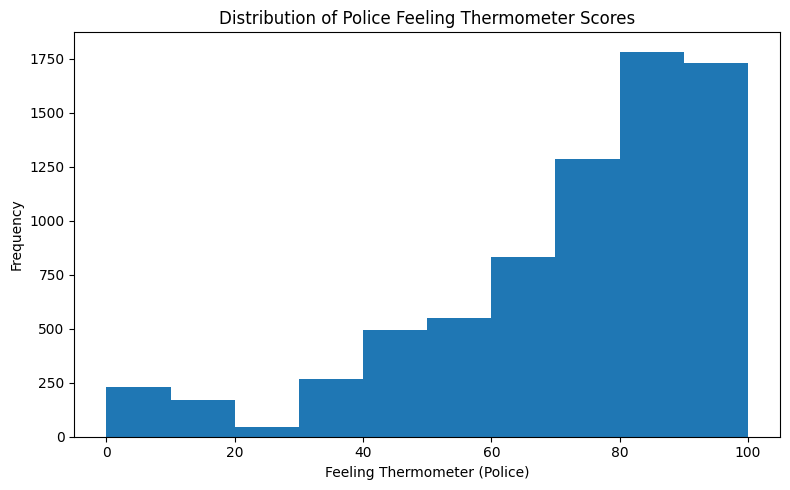

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(nes["ft_police"], bins=10)
plt.xlabel("Feeling Thermometer (Police)")
plt.ylabel("Frequency")
plt.title("Distribution of Police Feeling Thermometer Scores")
plt.tight_layout()
plt.show()

If `matplotlib` feels clunky compared to `ggplot2`, try `seaborn` (built on matplotlib, nicer defaults) or `plotly` (interactive).

/tmp/ipykernel_2249/1647230411.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


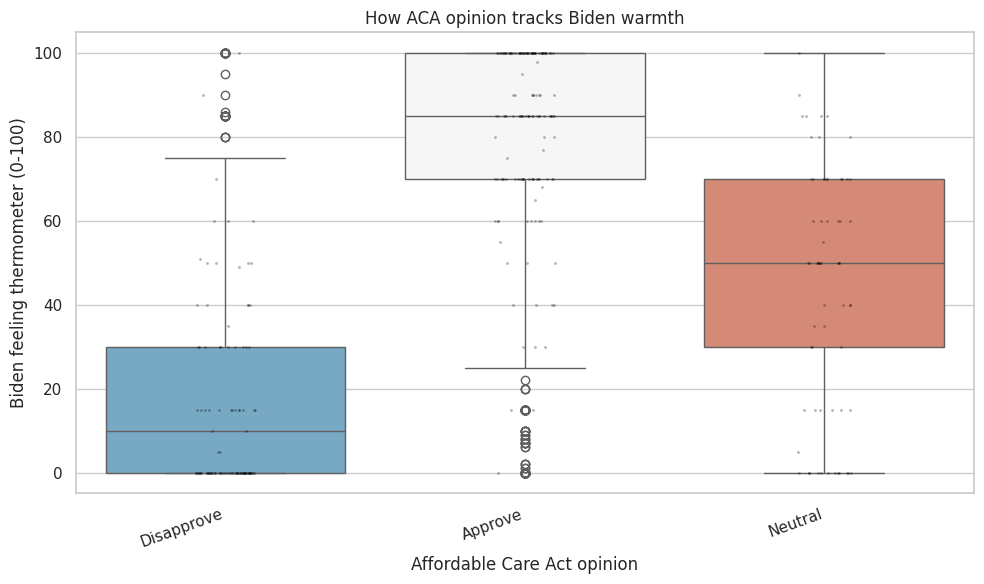

In [106]:
import seaborn as sns

## we can set themes in seaborn
sns.set_theme(style="whitegrid", context="notebook") # can be saved as poster or slide or notebook

plot_data = nes.dropna(subset=["ft_biden", "aca"])


fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_data,
    x="aca", y="ft_biden",
    palette="RdBu_r", #color palate
    ax=ax,
)


sns.stripplot(
    data=plot_data.sample(min(300, len(plot_data))),
    x="aca", y="ft_biden",
    color="black", alpha=0.3, size=2,
    ax=ax,
)


ax.set_xlabel("Affordable Care Act opinion")
ax.set_ylabel("Biden feeling thermometer (0-100)")
ax.set_title("How ACA opinion tracks Biden warmth")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

#chetsheet https://matplotlib.org/cheatsheets/

style="whitegrid": white background with light gridlines (other options: "darkgrid", "white", "ticks", "dark")

context="notebook": sizes labels and lines for a notebook display (other options: "paper", "talk", "poster", each progressively bigger for different output contexts)


figsize=(10, 6) sets the dimensions in inches. 10 wide × 6 tall gives room for the rotated category labels at the bottom.


**What's the weird Ax = Ax thing**?

sns.boxplot(data=df, x="aca", y="ft_biden"), seaborn:

- Splits the data by aca values for you
- Computes the quartiles for each group
- Picks reasonable colors
- builds the legend
- returns the result as a matplotlib axes object

That last part is important: seaborn doesn't replace matplotlib. Anything seaborn draws lives inside a matplotlib Axes.

The two objects:

Figure — the whole image. Think of it as the page or canvas. Holds one or more axes.

Axes — a single chart area within the figure. Has its own x-axis, y-axis, title, legend.

When you write fig, ax = plt.subplots(figsize=(10, 6)), you get:


a Figure (size 10×6 inches), and
a single Axes inside it.

If you wanted a 2×2 grid of charts, you'd write fig, axes = plt.subplots(2, 2) and get one figure containing four axes.

Why ax=ax:

When you call sns.boxplot(...) without ax=, seaborn creates its own figure and axes, which is fine for a one-off, but you've lost the handle. Anything you want to customize (labels, ticks, layered plots) needs an ax you can modify.
By writing ax=ax, you're telling seaborn "draw your chart onto this specific axes I already created." That keeps the axes object in your hands so you can:


Tweak with matplotlib methods — ax.set_xlabel(...), ax.set_title(...), ax.legend(...), etc.


sns.stripplot overlays the jittered raw points, so we get both the raw data and the distribution



In [ ]:
import plotly.express as px

fig = px.scatter(
    nes.dropna(subset=["ft_biden", "ft_trump", "aca"]),
    x="ft_biden",
    y="ft_trump",
    color="aca",
    opacity=0.5,
    title="Biden vs Trump feeling thermometers, by ACA opinion",
    labels={
        "ft_biden": "Biden FT",
        "ft_trump": "Trump FT",
        "aca": "ACA opinion",
    },
)
fig.show()

## Wrap-up

You've now seen the core of pandas:

- Series and DataFrames
- Filtering, updating, indexing (with `.iloc` for positional)
- Aggregating with `.groupby` and `.agg`
- Merging DataFrames
- Handling missing values
- Vectorized string operations with `.str`
- Custom transforms with `.apply`

Most data analysis  is a recombination of these building blocks. Tomorrow we'll move on to web scraping and text-as-data.